# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Курс data analyst/Python/Візуалізація/yulu_rental.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

Даних в наборі 10886 та має погодинний рівень деталізації.


In [ ]:
df.shape


(10886, 19)

In [ ]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [ ]:
day_count = df['count'].resample('D').sum()

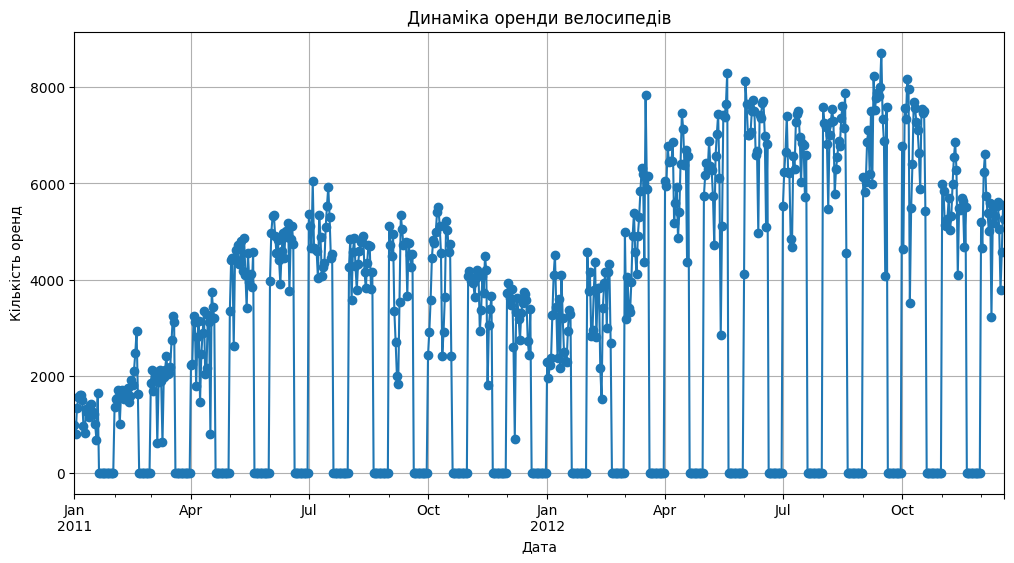

In [ ]:
day_count.plot(
   kind = 'line',
    marker = 'o',
    figsize=(12,6),
    title= 'Динаміка оренди велосипедів',
    xlabel='Дата',
    ylabel='Кількість оренд',
    grid=True
);

Дані в датасеті лише з 1 по 19 число місяця, тому є заломи. Для того, щоб прибрати заломи можна згрупувати за df.groupby('date')['count'].sum().
Тенденції зростаючі, бачимо зростання бізнесу в 2012 відносно 2011.
Так, найбільша активність помітна в теплі місяці літо, початок осені. Значене падіння бачимо в грудні-лютому.
Бачимо в сприятливий період низькі значення, що пов'язано із несприятливою погодою. Сплески спостерігаються у теплі сонячні дні.



## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

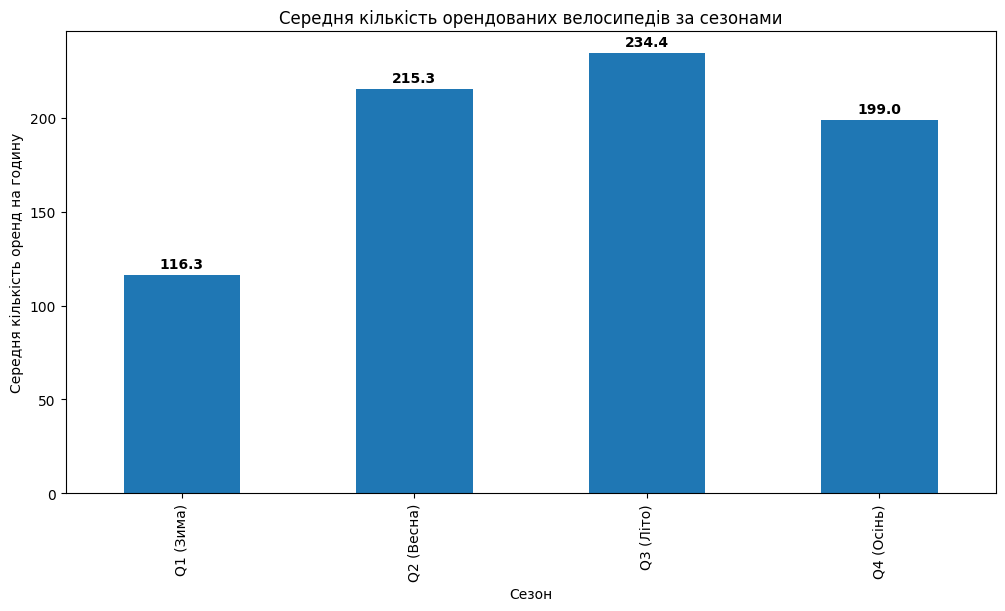

In [ ]:
mean_num_by_q = df.groupby('season')['count'].mean()
mean_num_by_q.index = ['Q1 (Зима)', 'Q2 (Весна)', 'Q3 (Літо)', 'Q4 (Осінь)']
ax = mean_num_by_q.plot.bar(
    figsize=(12,6),
    title='Середня кількість орендованих велосипедів за сезонами',
    xlabel= 'Сезон',
    ylabel = 'Середня кількість оренд на годину'
)
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3, fontweight='bold');

Найбільша середня кількість оренди влітку, найтепліший період з сприятливою погодою для прогулянок.
Різниця оренди в найбільш та найменш популярні сезони: 234.4/116.3 = 2.0155

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [ ]:
mean_by_month = df.groupby('month')['count'].mean()

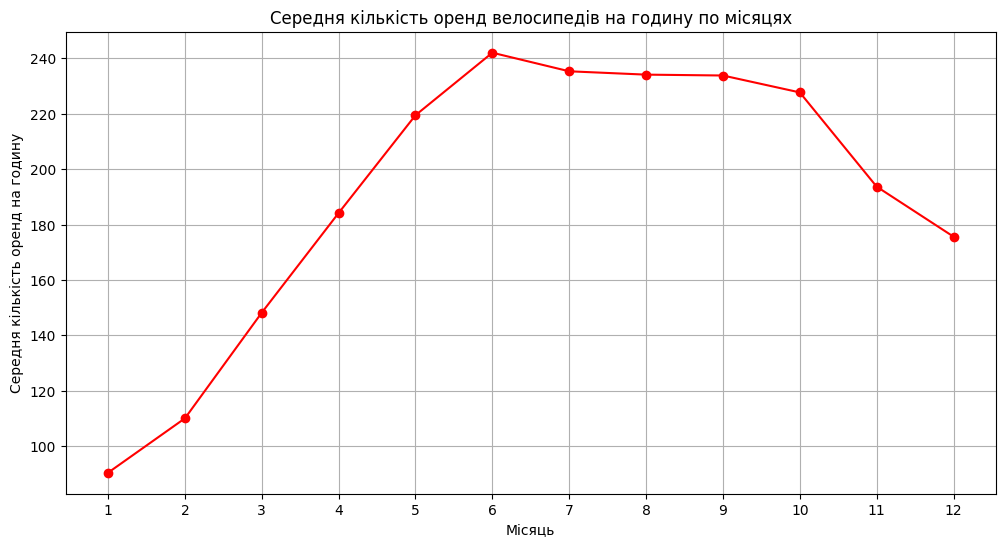

In [ ]:
mean_by_month.plot(
    kind='line',
    figsize=(12, 6),
    color='red',
    marker='o',
    grid=True,
    title='Середня кількість оренд велосипедів на годину по місяцях',
    xlabel='Місяць',
    ylabel='Середня кількість оренд на годину',
    xticks=range(1, 13)
);

Пік бачимо в 6 місяці, спад в 1. Закономірність повістю збігається з попереднім завданням. Температура повітня, к-сть опадів та тривалість світлового дня впливає на оренду.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

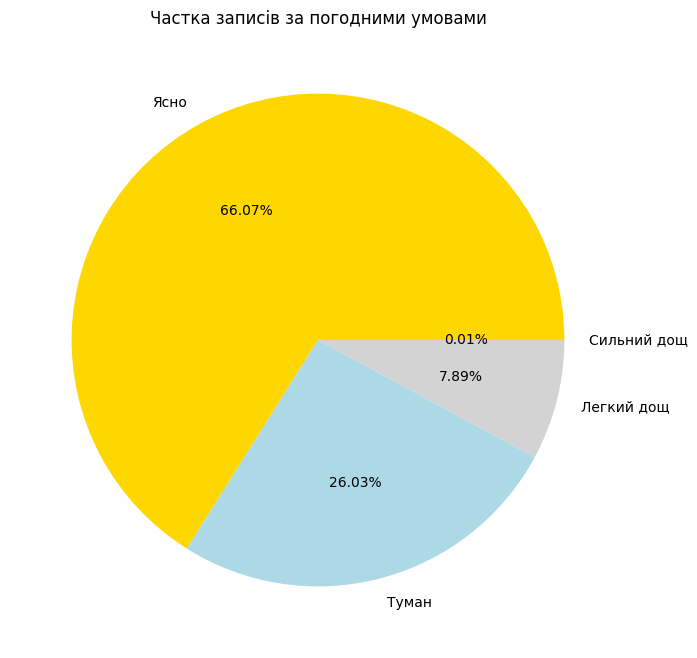

In [ ]:
weather_counts = df['weather'].value_counts().sort_index()

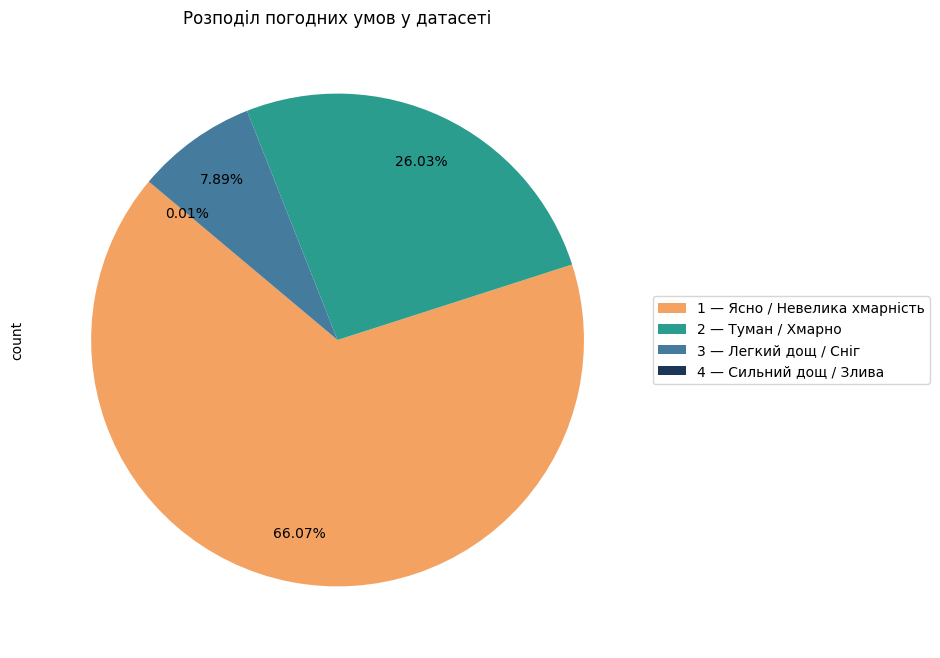

In [ ]:
custom_colors = ['#f4a261', '#2a9d8f', '#457b9d', '#1d3557']
weather_labels = [
    '1 — Ясно / Невелика хмарність',
    '2 — Туман / Хмарно',
    '3 — Легкий дощ / Сніг',
    '4 — Сильний дощ / Злива'
]
weather_counts.plot(
    kind='pie',
    figsize=(8, 8),
    autopct='%.2f%%',
    colors=custom_colors,
    labels=None,
    startangle=140,
    pctdistance=0.8,
    title='Розподіл погодних умов у датасеті'
)
plt.legend(weather_labels, loc='center left', bbox_to_anchor=(1.0, 0.5));

У датсеті переважає ясна погода, частка сильних дощів 0,01%.
Чим гірші погодні умови, тим нижчий попит. Ясна погода формує абсолютну більшість поїздок.



## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

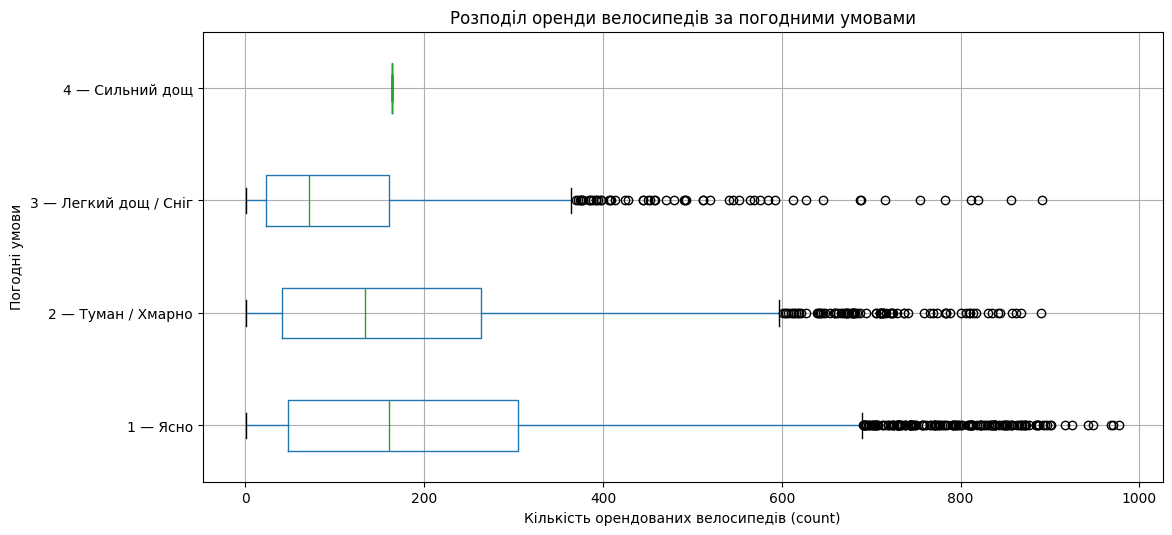

In [ ]:
weather_map = {
    1: '1 — Ясно',
    2: '2 — Туман / Хмарно',
    3: '3 — Легкий дощ / Сніг',
    4: '4 — Сильний дощ'
}

df['weather_label'] = df['weather'].map(weather_map)

df.boxplot(
    column='count',
    by='weather_label',
    vert=False,
    figsize=(12, 6),
    grid=True
)

plt.title('Розподіл оренди велосипедів за погодними умовами')
plt.suptitle('')
plt.xlabel('Кількість орендованих велосипедів (count)')
plt.ylabel('Погодні умови');

Найбільший розкид к-сті оренди при ясній погоді.
Викиди присутні скрізь, крім категорії сильний дощ, оскільки там лише один рядок спостережень.
При ясній погоді медіанне значення найвище.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

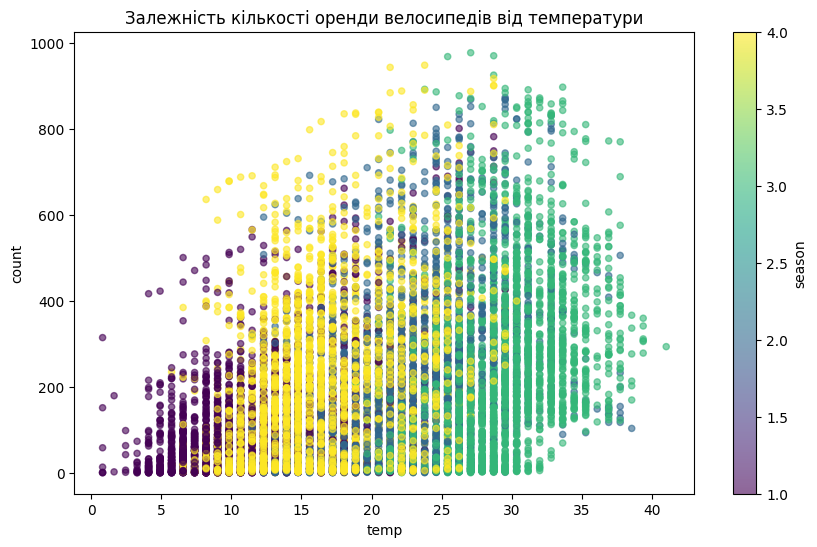

In [ ]:
df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    title='Залежність кількості оренди велосипедів від температури',
    figsize=(10, 6),
    alpha=0.6
);

У діапазоні комфортної теплої погоди ($20^\circ\text{C} - 32^\circ\text{C}$) спостерігається найбільша концентрація високих значень (до 800–1000 оренд).
Якщо температура перевищує $35^\circ\text{C}$, попит перестає зростати і навіть дещо знижується, оскільки за сильної спеки фізична активність стає менш комфортною.


## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

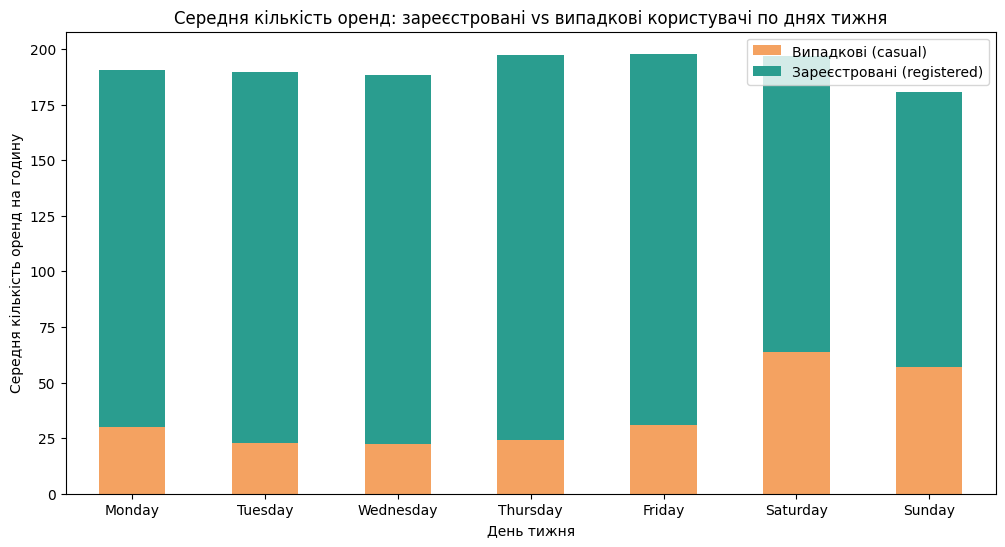

In [ ]:
weekly_users = df.groupby(['weekday_num', 'weekday'])[['casual', 'registered']].mean()
weekly_users = weekly_users.droplevel('weekday_num')

weekly_users.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['#f4a261', '#2a9d8f'],
    rot=0,
    grid=False,
    title='Середня кількість оренд: зареєстровані vs випадкові користувачі по днях тижня',
    xlabel='День тижня',
    ylabel='Середня кількість оренд на годину'
)
plt.legend(['Випадкові (casual)', 'Зареєстровані (registered)'], loc='upper right');

Найбільше оренд від зареєстрованих користувачів спостервгається в робочі дні.
Випадкові користувачі, це зазвичай туристи або люди, які користуються ними для відпочинку, прогулянок, тому їх у будні дні мінімум, а у вихідні - максимум.